<a href="https://colab.research.google.com/github/ansmalik67/nanSense-ds-hack/blob/issaku_branch/nansense_ds_hack.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# H1N1 Vaccine Prediction — Random Forest

This Colab notebook performs EDA, preprocessing, model training, validation, and final prediction file generation for the **Random Forest** model.

Target variable: `h1n1_vaccine`.

## 1. Import Libraries

In [39]:

# Core libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Machine learning
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report, RocCurveDisplay

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

RANDOM_STATE = 42

from sklearn.ensemble import RandomForestClassifier

## 2. Load Training and Testing Data


In [40]:


TRAIN_PATH = 'dataset_B_training.csv'
TEST_PATH = 'dataset_B_testing.csv'

train_df = pd.read_csv(TRAIN_PATH)
test_df = pd.read_csv(TEST_PATH)

print('Training shape:', train_df.shape)
print('Testing shape:', test_df.shape)
train_df.head()


Training shape: (4756, 31)
Testing shape: (4749, 30)


,respondent_id,h1n1_concern,h1n1_knowledge,behavioral_antiviral_meds,behavioral_avoidance,behavioral_face_mask,behavioral_wash_hands,behavioral_large_gatherings,behavioral_outside_home,behavioral_touch_face,doctor_recc_h1n1,chronic_med_condition,child_under_6_months,health_worker,health_insurance,opinion_h1n1_vacc_effective,opinion_h1n1_risk,opinion_h1n1_sick_from_vacc,age_group,education,race,sex,income_poverty,marital_status,rent_or_own,employment_status,census_msa,household_adults,household_children,employment_sector,h1n1_vaccine
0,1,1.0,2.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,4.0,4.0,1.0,45 - 54 Years,Some College,White,Female,"<= $75,000, Above Poverty",Married,Own,Employed,"MSA, Not Principle City",2.0,1.0,science,0
1,2,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,3.0,1.0,2.0,18 - 34 Years,Some College,White,Female,Below Poverty,Not Married,Own,Employed,Non-MSA,0.0,3.0,wholesale,0
2,3,2.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,NaN,0.0,0.0,0.0,1.0,3.0,4.0,2.0,45 - 54 Years,College Graduate,White,Female,"> $75,000",Not Married,Own,Employed,"MSA, Principle City",0.0,0.0,education,1
3,4,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,2.0,1.0,4.0,18 - 34 Years,College Graduate,White,Female,"<= $75,000, Above Poverty",Not Married,Rent,Not in Labor Force,Non-MSA,0.0,0.0,NaN,0
4,5,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,NaN,2.0,2.0,1.0,18 - 34 Years,< 12 Years,White,Female,NaN,Not Married,NaN,Unemployed,Non-MSA,3.0,0.0,NaN,0


## 3. Basic EDA
This section checks column names, data types, and sample rows.

In [41]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4756 entries, 0 to 4755
Data columns (total 31 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   respondent_id                4756 non-null   int64  
 1   h1n1_concern                 4741 non-null   float64
 2   h1n1_knowledge               4734 non-null   float64
 3   behavioral_antiviral_meds    4739 non-null   float64
 4   behavioral_avoidance         4729 non-null   float64
 5   behavioral_face_mask         4752 non-null   float64
 6   behavioral_wash_hands        4748 non-null   float64
 7   behavioral_large_gatherings  4747 non-null   float64
 8   behavioral_outside_home      4741 non-null   float64
 9   behavioral_touch_face        4736 non-null   float64
 10  doctor_recc_h1n1             4437 non-null   float64
 11  chronic_med_condition        4595 non-null   float64
 12  child_under_6_months         4622 non-null   float64
 13  health_worker     

In [42]:
train_df.describe()

,respondent_id,h1n1_concern,h1n1_knowledge,behavioral_antiviral_meds,behavioral_avoidance,behavioral_face_mask,behavioral_wash_hands,behavioral_large_gatherings,behavioral_outside_home,behavioral_touch_face,doctor_recc_h1n1,chronic_med_condition,child_under_6_months,health_worker,health_insurance,opinion_h1n1_vacc_effective,opinion_h1n1_risk,opinion_h1n1_sick_from_vacc,household_adults,household_children,h1n1_vaccine
count,4756.00000,4741.000000,4734.000000,4739.000000,4729.000000,4752.000000,4748.000000,4747.000000,4741.000000,4736.000000,4437.000000,4595.000000,4622.000000,4625.000000,2831.000000,4687.000000,4692.000000,4692.000000,4722.000000,4722.000000,4756.000000
mean,2378.50000,1.658933,1.307140,0.057396,0.740960,0.077652,0.842039,0.359385,0.341278,0.704814,0.290286,0.314037,0.090437,0.141189,0.901801,3.965436,2.512361,2.412191,0.888818,0.542143,0.394029
std,1373.08327,0.892478,0.612811,0.232622,0.438154,0.267651,0.364743,0.479871,0.474189,0.456174,0.453946,0.464182,0.286838,0.348254,0.297635,0.981737,1.336426,1.372509,0.755777,0.931243,0.488692
min,1.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000
25%,1189.75000,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,4.000000,1.000000,1.000000,0.000000,0.000000,0.000000
50%,2378.50000,2.000000,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,4.000000,2.000000,2.000000,1.000000,0.000000,0.000000
75%,3567.25000,2.000000,2.000000,0.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,1.000000,5.000000,4.000000,4.000000,1.000000,1.000000,1.000000
max,4756.00000,3.000000,2.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,5.000000,5.000000,5.000000,3.000000,3.000000,1.000000


## 4. Missing Value Analysis
This shows which columns have missing values and how serious the missingness is.

,missing_count,missing_percent
employment_sector,2364,49.71
health_insurance,1925,40.48
income_poverty,712,14.97
doctor_recc_h1n1,319,6.71
rent_or_own,315,6.62
employment_status,235,4.94
marital_status,226,4.75
education,224,4.71
chronic_med_condition,161,3.39
child_under_6_months,134,2.82


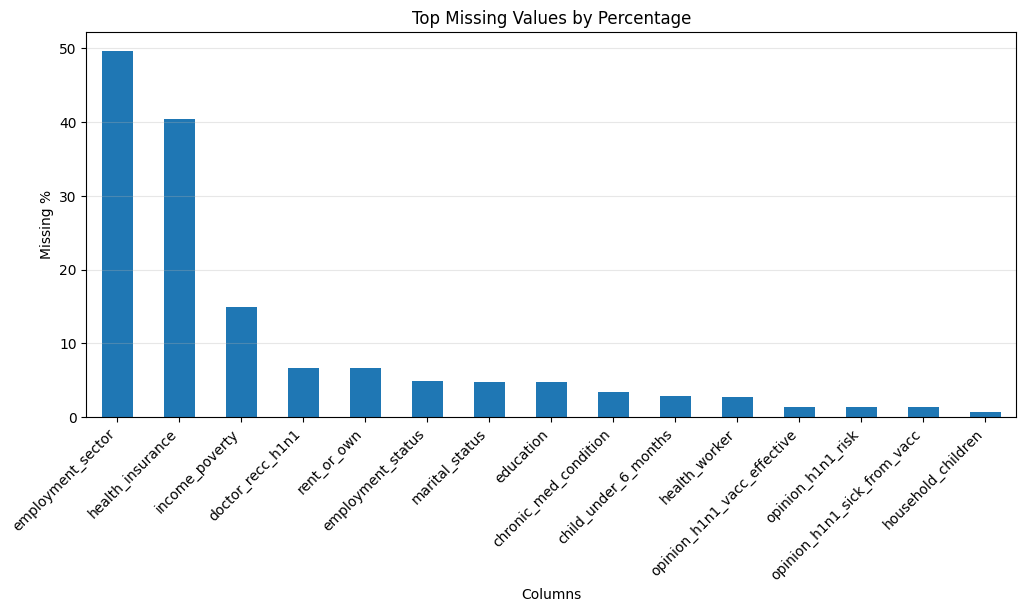

In [43]:

# Missing value analysis
missing = train_df.isnull().sum().sort_values(ascending=False)
missing_percent = (missing / len(train_df) * 100).round(2)
missing_table = pd.DataFrame({
    'missing_count': missing,
    'missing_percent': missing_percent
})
display(missing_table[missing_table['missing_count'] > 0])

# Plot top missing columns
missing_table[missing_table['missing_count'] > 0]['missing_percent'].head(15).plot(kind='bar', figsize=(12, 5))
plt.title('Top Missing Values by Percentage')
plt.ylabel('Missing %')
plt.xlabel('Columns')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.show()


In [44]:
# Separate columns
numeric_cols = train_df.select_dtypes(include=['int64', 'float64']).columns
categorical_cols = train_df.select_dtypes(include=['object']).columns

# Fill numeric columns with median
for col in numeric_cols:
    train_df[col] = train_df[col].fillna(train_df[col].median())

# Fill categorical columns with mode
for col in categorical_cols:
    train_df[col] =train_df[col].fillna(train_df[col].mode()[0])

print(train_df.isnull().sum().sum())

0


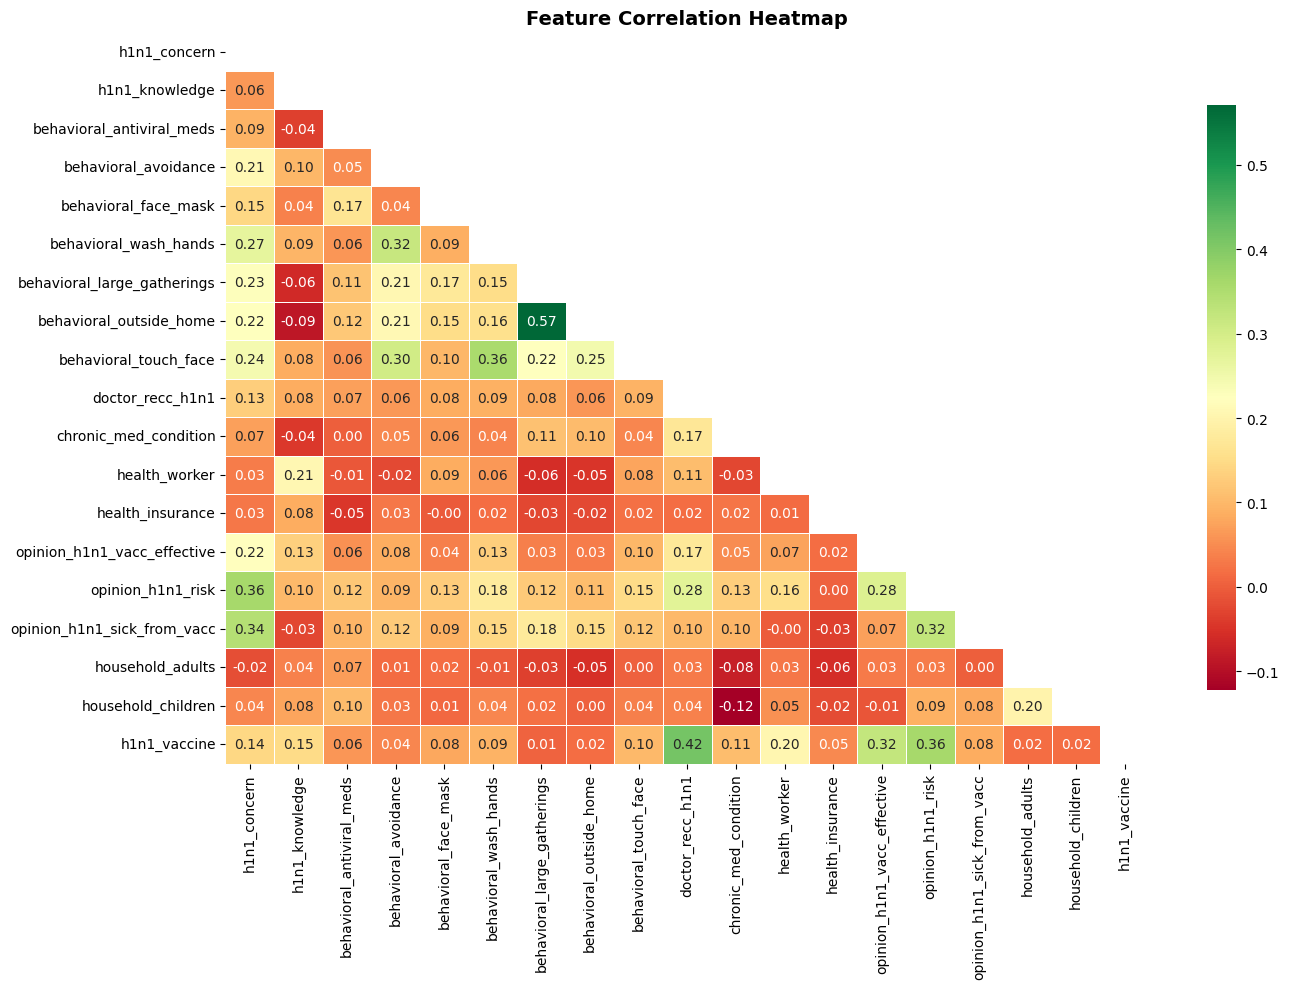

Figure saved: correlation_heatmap.png


In [45]:
# --- Correlation heatmap (numeric features) ---
num_cols = [
    'h1n1_concern', 'h1n1_knowledge', 'behavioral_antiviral_meds',
    'behavioral_avoidance', 'behavioral_face_mask', 'behavioral_wash_hands',
    'behavioral_large_gatherings', 'behavioral_outside_home', 'behavioral_touch_face',
    'doctor_recc_h1n1', 'chronic_med_condition', 'health_worker', 'health_insurance',
    'opinion_h1n1_vacc_effective', 'opinion_h1n1_risk', 'opinion_h1n1_sick_from_vacc',
    'household_adults', 'household_children', 'h1n1_vaccine'
]

plt.figure(figsize=(14, 10))
corr = train_df[num_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved: correlation_heatmap.png')

## 5. Target Variable Analysis
This checks whether the target classes are balanced or imbalanced.

h1n1_vaccine
0    2882
1    1874
Name: count, dtype: int64

Target percentage:
h1n1_vaccine
0    60.6
1    39.4
Name: proportion, dtype: float64


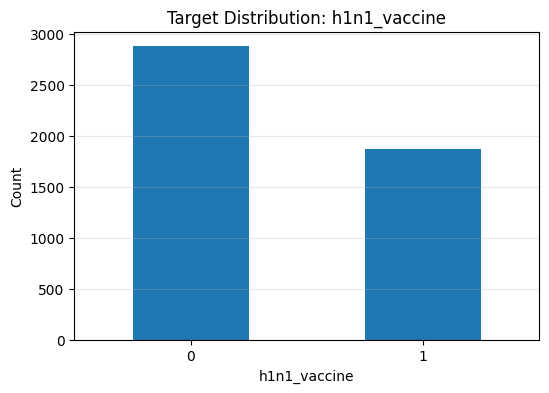

In [46]:

# Target variable distribution
TARGET = 'h1n1_vaccine'
ID_COL = 'respondent_id'

print(train_df[TARGET].value_counts())
print('\nTarget percentage:')
print((train_df[TARGET].value_counts(normalize=True) * 100).round(2))

train_df[TARGET].value_counts().plot(kind='bar', figsize=(6, 4))
plt.title('Target Distribution: h1n1_vaccine')
plt.xlabel('h1n1_vaccine')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)
plt.show()


In [47]:
!pip install imbalanced-learn

## 6. Numeric Feature EDA
This shows summary statistics and distributions for numerical/ordinal features.

Numeric columns: 19
['h1n1_concern', 'h1n1_knowledge', 'behavioral_antiviral_meds', 'behavioral_avoidance', 'behavioral_face_mask', 'behavioral_wash_hands', 'behavioral_large_gatherings', 'behavioral_outside_home', 'behavioral_touch_face', 'doctor_recc_h1n1', 'chronic_med_condition', 'child_under_6_months', 'health_worker', 'health_insurance', 'opinion_h1n1_vacc_effective', 'opinion_h1n1_risk', 'opinion_h1n1_sick_from_vacc', 'household_adults', 'household_children']

Categorical columns: 10
['age_group', 'education', 'race', 'sex', 'income_poverty', 'marital_status', 'rent_or_own', 'employment_status', 'census_msa', 'employment_sector']


,count,mean,std,min,25%,50%,75%,max
h1n1_concern,4741.0,1.658933,0.892478,0.0,1.0,2.0,2.0,3.0
h1n1_knowledge,4734.0,1.307140,0.612811,0.0,1.0,1.0,2.0,2.0
behavioral_antiviral_meds,4739.0,0.057396,0.232622,0.0,0.0,0.0,0.0,1.0
behavioral_avoidance,4729.0,0.740960,0.438154,0.0,0.0,1.0,1.0,1.0
behavioral_face_mask,4752.0,0.077652,0.267651,0.0,0.0,0.0,0.0,1.0
behavioral_wash_hands,4748.0,0.842039,0.364743,0.0,1.0,1.0,1.0,1.0
behavioral_large_gatherings,4747.0,0.359385,0.479871,0.0,0.0,0.0,1.0,1.0
behavioral_outside_home,4741.0,0.341278,0.474189,0.0,0.0,0.0,1.0,1.0
behavioral_touch_face,4736.0,0.704814,0.456174,0.0,0.0,1.0,1.0,1.0
doctor_recc_h1n1,4437.0,0.290286,0.453946,0.0,0.0,0.0,1.0,1.0


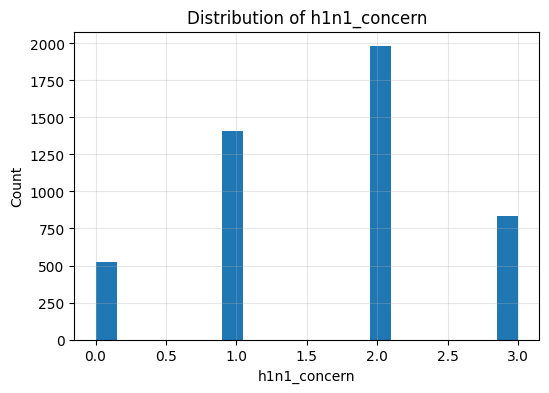

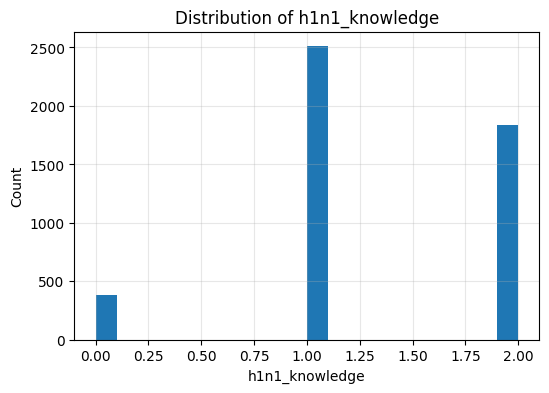

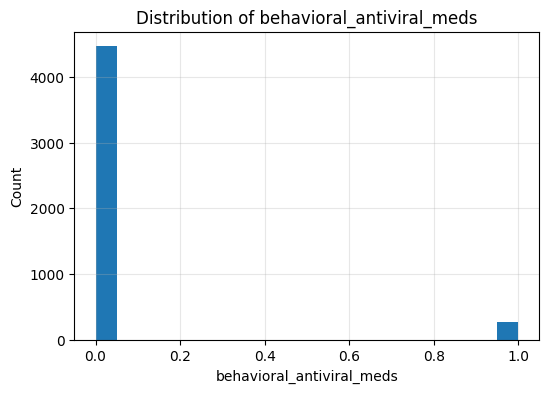

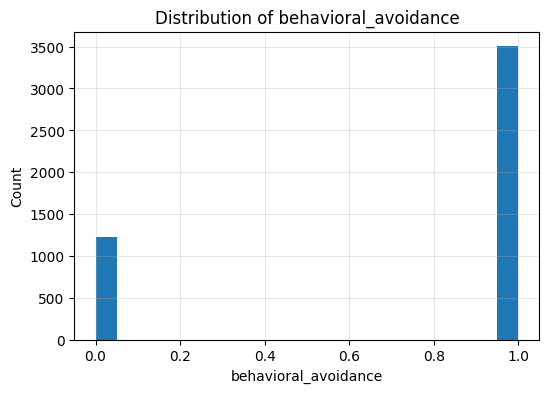

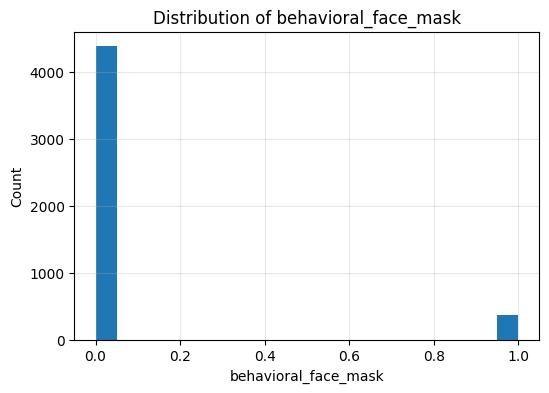

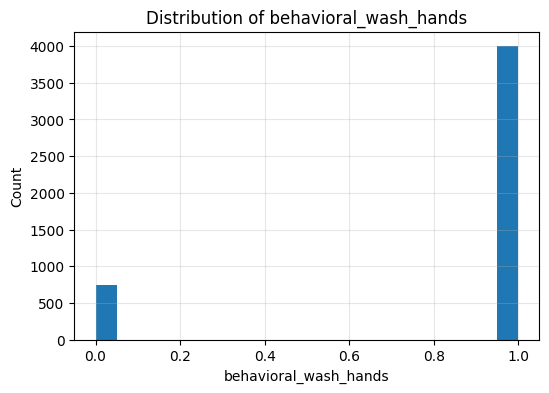

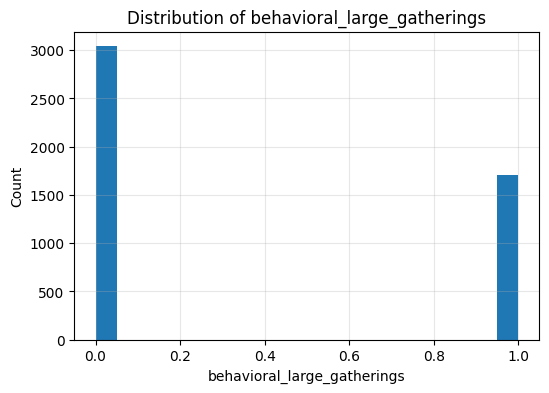

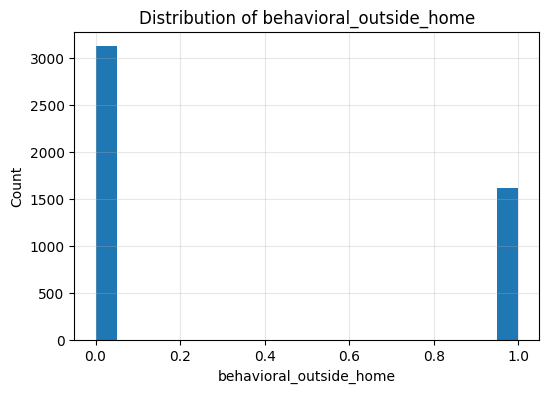

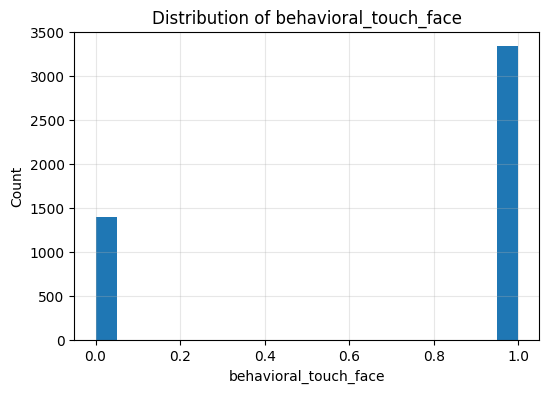

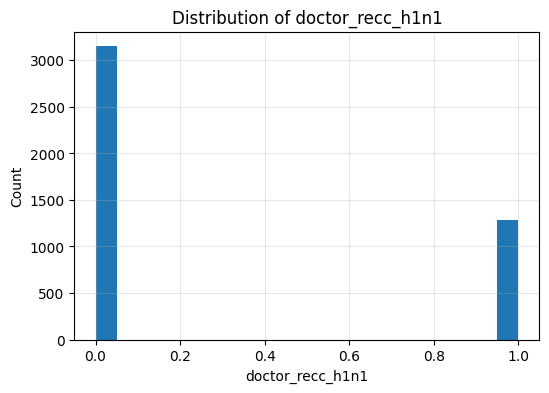

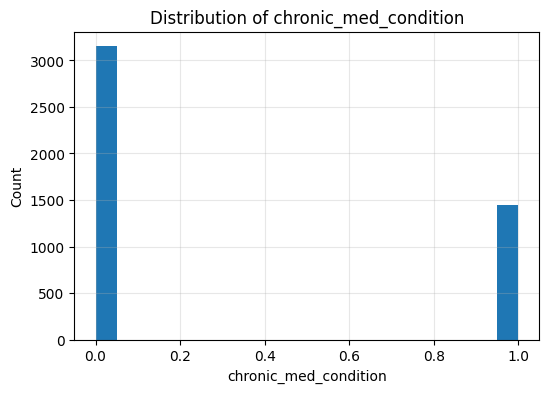

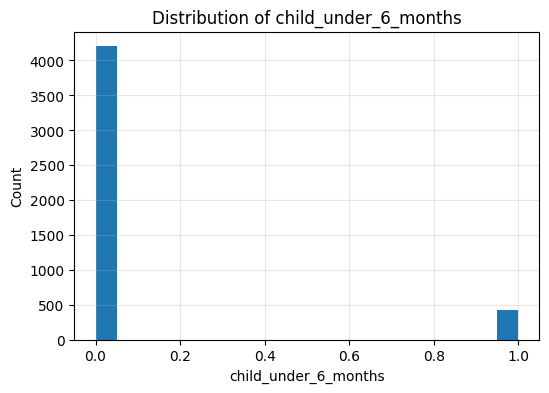

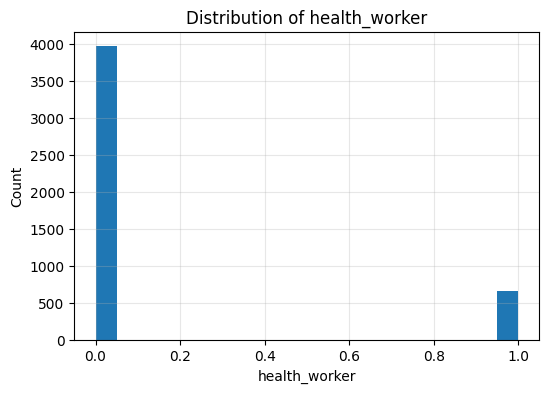

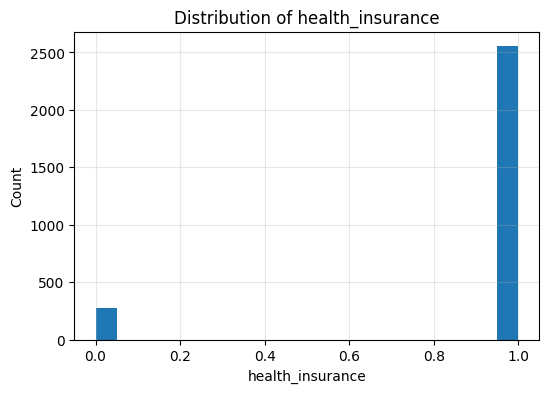

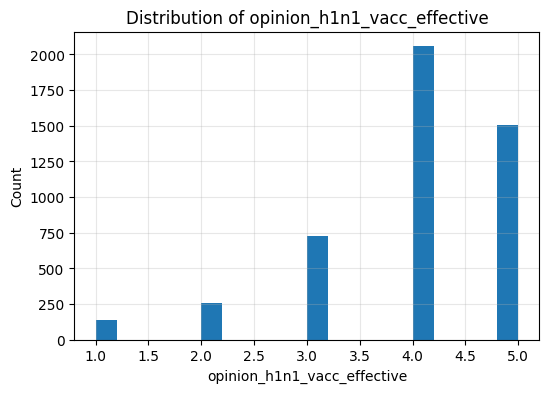

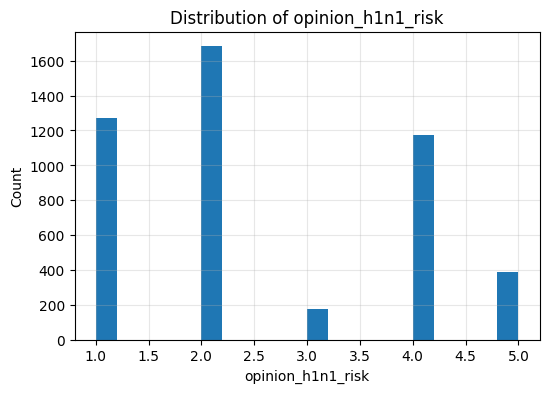

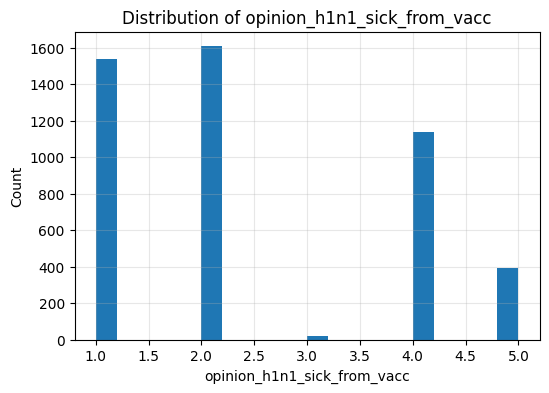

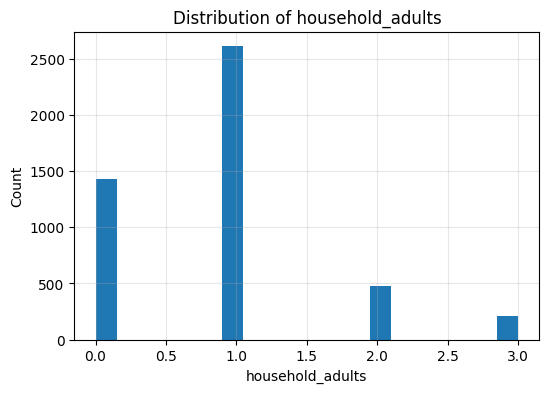

In [24]:

# Numerical / ordinal feature summary
numeric_cols = train_df.drop(columns=[TARGET, ID_COL]).select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = train_df.drop(columns=[TARGET, ID_COL]).select_dtypes(include=['object']).columns.tolist()

print('Numeric columns:', len(numeric_cols))
print(numeric_cols)
print('\nCategorical columns:', len(cat_cols))
print(cat_cols)

display(train_df[numeric_cols].describe().T)

# Histograms for numeric columns
for col in numeric_cols[:18]:
    plt.figure(figsize=(6, 4))
    train_df[col].hist(bins=20)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.grid(alpha=0.3)
    plt.show()


## 7. Categorical Feature EDA
This checks categories such as age group, education, race, sex, income, and employment.


age_group


,count
age_group,
65+ Years,1225
55 - 64 Years,1065
45 - 54 Years,913
18 - 34 Years,894
35 - 44 Years,659


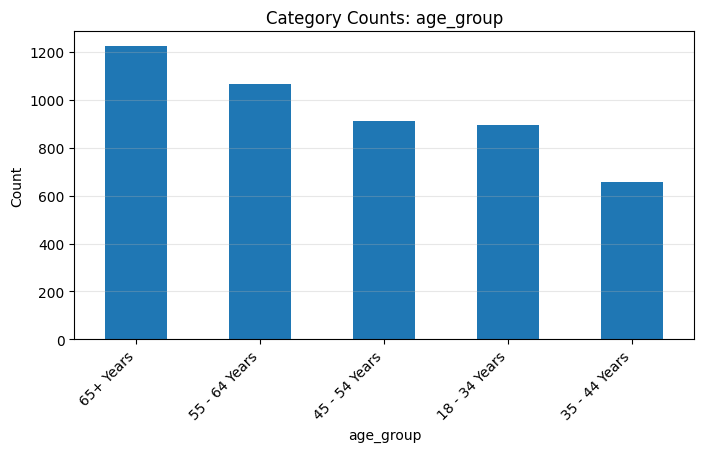


education


,count
education,
College Graduate,1858
Some College,1270
12 Years,1009
< 12 Years,395
NaN,224


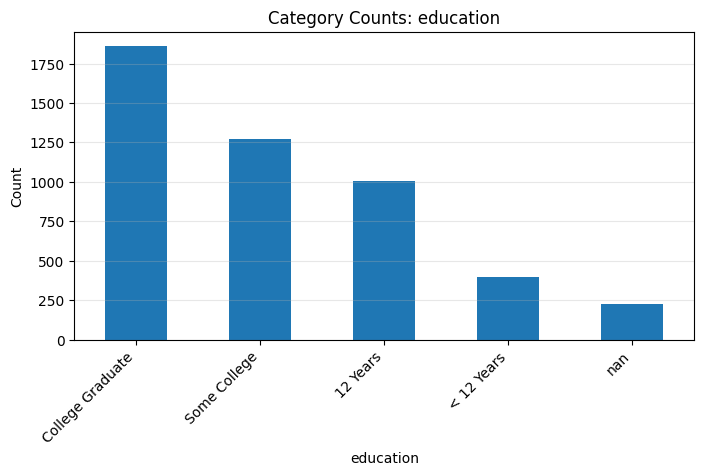


race


,count
race,
White,3831
Black,324
Other or Multiple,305
Hispanic,296


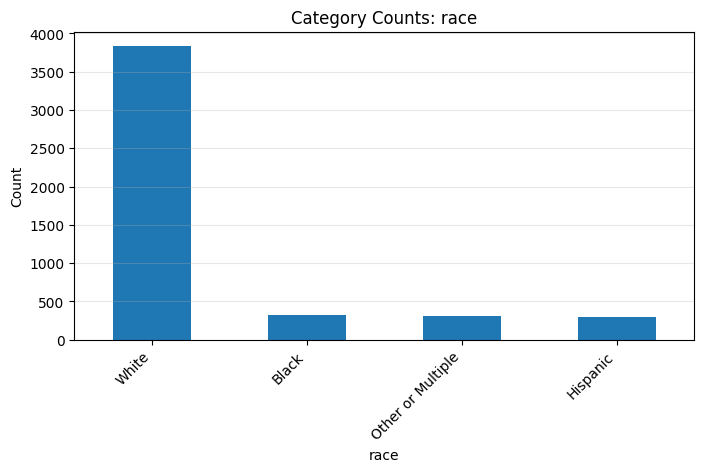


sex


,count
sex,
Female,2921
Male,1835


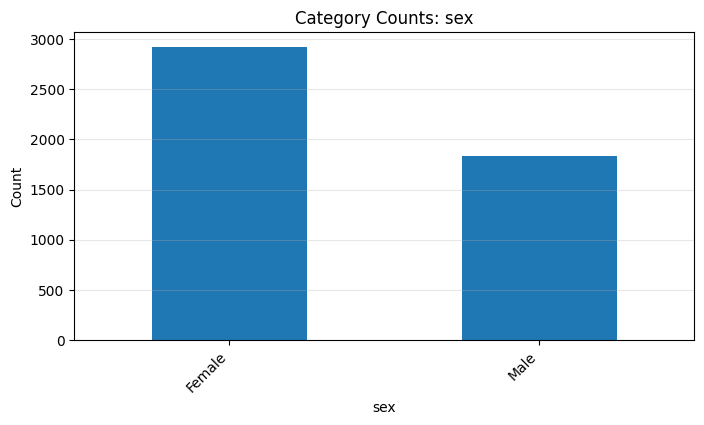


income_poverty


,count
income_poverty,
"<= $75,000, Above Poverty",2250
"> $75,000",1342
NaN,712
Below Poverty,452


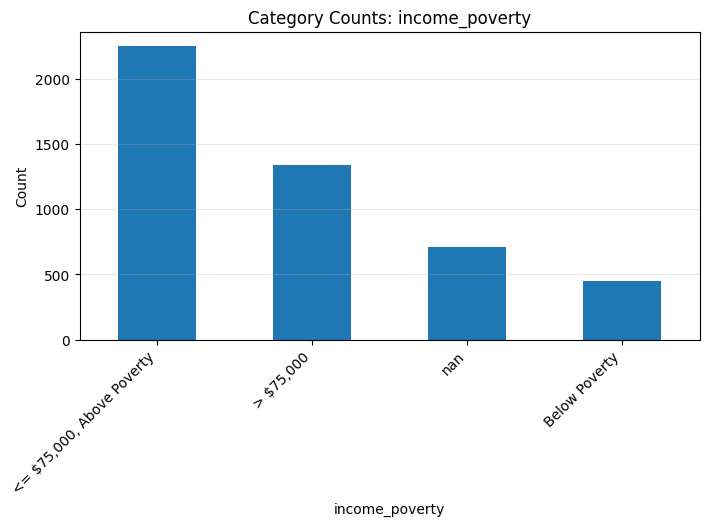


marital_status


,count
marital_status,
Married,2535
Not Married,1995
NaN,226


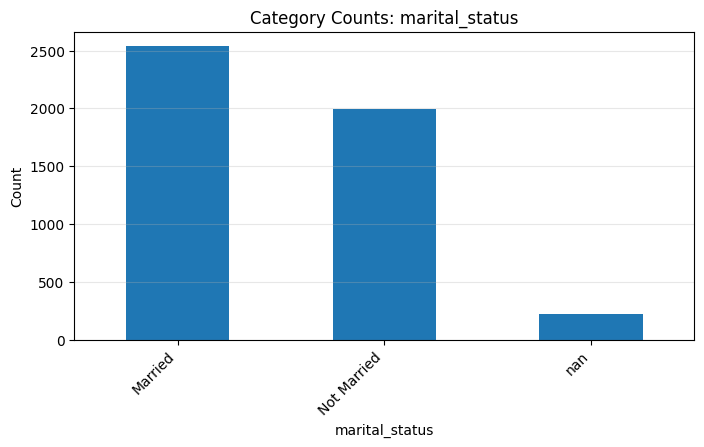


rent_or_own


,count
rent_or_own,
Own,3466
Rent,975
NaN,315


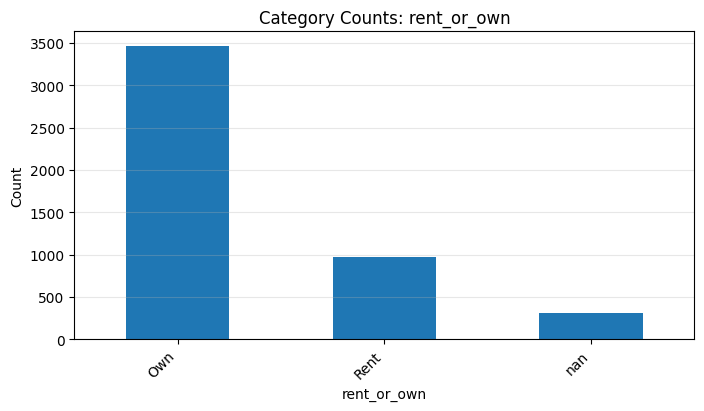


employment_status


,count
employment_status,
Employed,2419
Not in Labor Force,1838
Unemployed,264
NaN,235


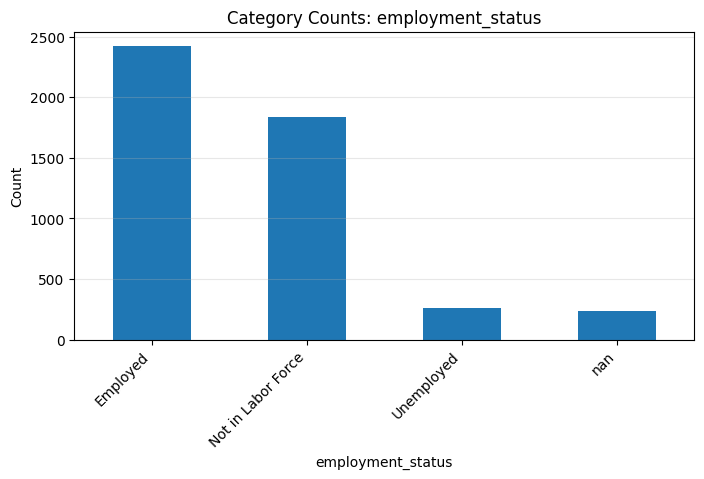


census_msa


,count
census_msa,
"MSA, Not Principle City",2120
"MSA, Principle City",1383
Non-MSA,1253


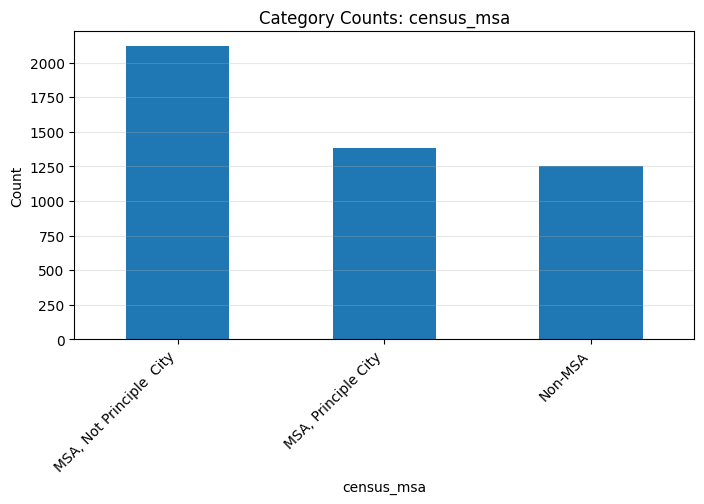


employment_sector


,count
employment_sector,
NaN,2364
healthcare,546
science,320
wholesale,211
education,179
construction,168
agriculture,162
utilities,120
finance,96


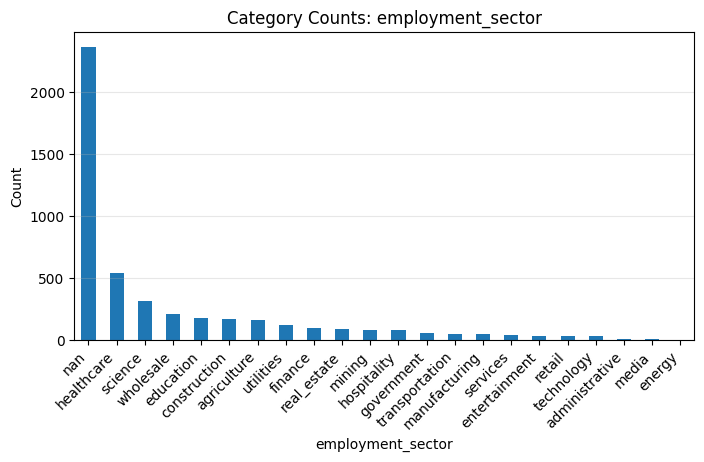

In [25]:

# Categorical feature analysis
for col in cat_cols:
    print('\n' + '='*60)
    print(col)
    display(train_df[col].value_counts(dropna=False).to_frame('count'))
    train_df[col].value_counts(dropna=False).plot(kind='bar', figsize=(8, 4))
    plt.title(f'Category Counts: {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.xticks(rotation=45, ha='right')
    plt.grid(axis='y', alpha=0.3)
    plt.show()


## 8. Correlation Analysis
This checks which numeric/ordinal features are most related to `h1n1_vaccine`.

,correlation_with_h1n1_vaccine
doctor_recc_h1n1,0.413874
opinion_h1n1_risk,0.362183
opinion_h1n1_vacc_effective,0.325057
health_worker,0.205428
h1n1_knowledge,0.148766
h1n1_concern,0.143235
health_insurance,0.129246
chronic_med_condition,0.107138
behavioral_touch_face,0.103222
behavioral_wash_hands,0.092827


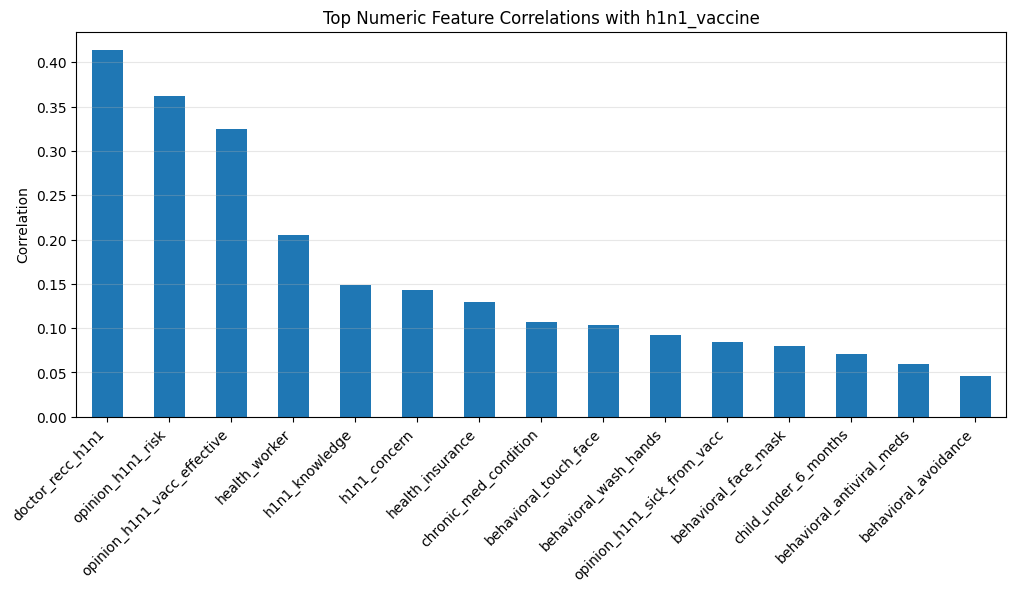

In [26]:

# Correlation with target for numeric/ordinal variables
corr_data = train_df[numeric_cols + [TARGET]].corr(numeric_only=True)[TARGET].drop(TARGET).sort_values(key=abs, ascending=False)
display(corr_data.to_frame('correlation_with_h1n1_vaccine'))

corr_data.head(15).plot(kind='bar', figsize=(12, 5))
plt.title('Top Numeric Feature Correlations with h1n1_vaccine')
plt.ylabel('Correlation')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.show()


## 9. Preprocessing
Missing numeric values are filled using median. Missing categorical values are filled using most frequent value. Categorical variables are converted using one-hot encoding.

In [27]:

# Prepare features and target
X = train_df.drop(columns=[TARGET, ID_COL])
y = train_df[TARGET]
X_test_final = test_df.drop(columns=[ID_COL])

numeric_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object']).columns.tolist()

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print('X_train:', X_train.shape)
print('X_valid:', X_valid.shape)
print('X_test_final:', X_test_final.shape)


X_train: (3804, 29)
X_valid: (952, 29)
X_test_final: (4749, 29)


## 10. Train and Evaluate Random Forest

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Random Forest,0.741597,0.676712,0.658667,0.667568,0.800739



Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.80      0.79       577
           1       0.68      0.66      0.67       375

    accuracy                           0.74       952
   macro avg       0.73      0.73      0.73       952
weighted avg       0.74      0.74      0.74       952


Confusion Matrix:


,Predicted 0,Predicted 1
Actual 0,459,118
Actual 1,128,247


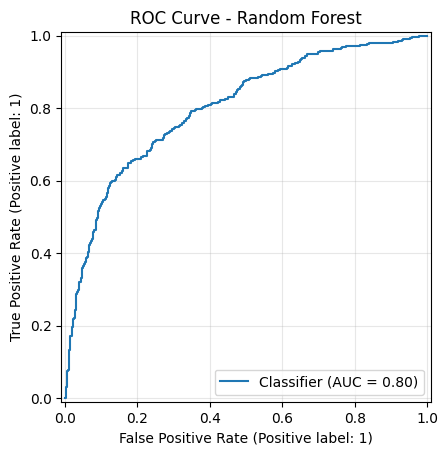

In [28]:

# Build and train the Random Forest model
model = RandomForestClassifier(n_estimators=300, max_depth=None, min_samples_split=4, min_samples_leaf=2, class_weight='balanced', random_state=42, n_jobs=-1)

clf = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', model)
])

clf.fit(X_train, y_train)

# Validation predictions
valid_pred = clf.predict(X_valid)
valid_proba = clf.predict_proba(X_valid)[:, 1]

metrics = {
    'Model': 'Random Forest',
    'Accuracy': accuracy_score(y_valid, valid_pred),
    'Precision': precision_score(y_valid, valid_pred, zero_division=0),
    'Recall': recall_score(y_valid, valid_pred, zero_division=0),
    'F1 Score': f1_score(y_valid, valid_pred, zero_division=0),
    'ROC AUC': roc_auc_score(y_valid, valid_proba)
}

metrics_df = pd.DataFrame([metrics])
display(metrics_df)

print('\nClassification Report:')
print(classification_report(y_valid, valid_pred, zero_division=0))

print('\nConfusion Matrix:')
cm = confusion_matrix(y_valid, valid_pred)
display(pd.DataFrame(cm, index=['Actual 0', 'Actual 1'], columns=['Predicted 0', 'Predicted 1']))

RocCurveDisplay.from_predictions(y_valid, valid_proba)
plt.title('ROC Curve - Random Forest')
plt.grid(alpha=0.3)
plt.show()


## 11. Feature Importance / Coefficients
This helps explain which variables are influencing the prediction most.

,feature,importance
9,num__doctor_recc_h1n1,0.138206
15,num__opinion_h1n1_risk,0.114475
14,num__opinion_h1n1_vacc_effective,0.111272
0,num__h1n1_concern,0.036530
16,num__opinion_h1n1_sick_from_vacc,0.036160
1,num__h1n1_knowledge,0.028712
12,num__health_worker,0.026365
17,num__household_adults,0.024403
18,num__household_children,0.023149
10,num__chronic_med_condition,0.017146


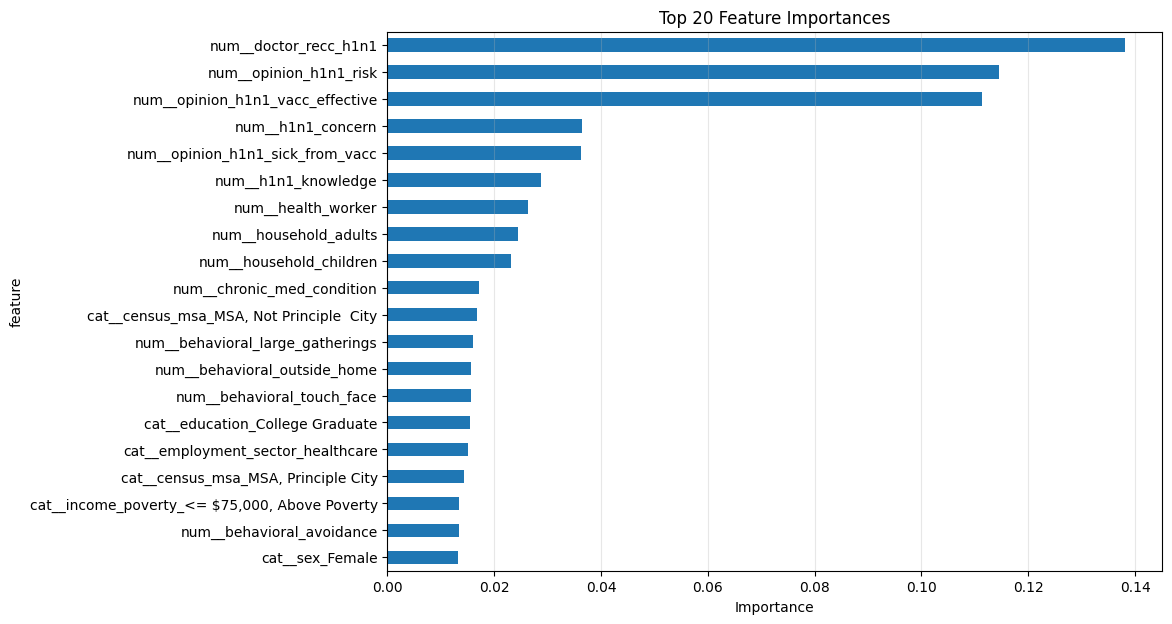

In [29]:

# Feature importance / coefficients where available
try:
    fitted_preprocessor = clf.named_steps['preprocessor']
    feature_names = fitted_preprocessor.get_feature_names_out()
    fitted_model = clf.named_steps['model']

    if hasattr(fitted_model, 'feature_importances_'):
        importance = fitted_model.feature_importances_
        importance_df = pd.DataFrame({'feature': feature_names, 'importance': importance})
        importance_df = importance_df.sort_values('importance', ascending=False).head(20)
        display(importance_df)
        importance_df.set_index('feature')['importance'].sort_values().plot(kind='barh', figsize=(10, 7))
        plt.title('Top 20 Feature Importances')
        plt.xlabel('Importance')
        plt.grid(axis='x', alpha=0.3)
        plt.show()
    elif hasattr(fitted_model, 'coef_'):
        coef = fitted_model.coef_[0]
        coef_df = pd.DataFrame({'feature': feature_names, 'coefficient': coef})
        coef_df['absolute_coefficient'] = coef_df['coefficient'].abs()
        coef_df = coef_df.sort_values('absolute_coefficient', ascending=False).head(20)
        display(coef_df)
        coef_df.sort_values('coefficient').set_index('feature')['coefficient'].plot(kind='barh', figsize=(10, 7))
        plt.title('Top 20 Logistic Regression Coefficients')
        plt.xlabel('Coefficient')
        plt.grid(axis='x', alpha=0.3)
        plt.show()
    else:
        print('This model does not provide direct feature importance or coefficients.')
except Exception as e:
    print('Could not create feature importance plot:', e)


## 12. Generate Final Test Prediction File
This trains the model on the full training dataset and creates a CSV file for test predictions.

In [30]:

# Train on full training data and create final test predictions
final_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(n_estimators=300, max_depth=None, min_samples_split=4, min_samples_leaf=2, class_weight='balanced', random_state=42, n_jobs=-1))
])

final_model.fit(X, y)

test_proba = final_model.predict_proba(X_test_final)[:, 1]
test_pred = (test_proba >= 0.5).astype(int)

submission = pd.DataFrame({
    'respondent_id': test_df[ID_COL],
    'h1n1_vaccine': test_pred,
    'h1n1_vaccine_probability': test_proba
})

output_file = '02_Random_Forest_H1N1_Model_submission.csv'
submission.to_csv(output_file, index=False)

print('Saved file:', output_file)
display(submission.head())


Saved file: 02_Random_Forest_H1N1_Model_submission.csv


,respondent_id,h1n1_vaccine,h1n1_vaccine_probability
0,4757,0,0.263582
1,4758,0,0.190455
2,4759,0,0.067064
3,4760,0,0.409658
4,4761,0,0.075723


## Simple Conclusion
The **Random Forest** model has been trained and evaluated using validation data. Use the ROC AUC, F1 score, precision, and recall to compare it with the other four notebooks. A higher ROC AUC usually means the model is better at separating vaccinated and non-vaccinated respondents.